In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/results/outputs/Group Pipeline (One-Hot).csv')

In [7]:
# 3. DEFINE X (FEATURES) AND y (TARGET)
y = df['Sales']
# X is all columns EXCEPT the target 'Sales' and the 'Game Title' identifier
X = df.drop(['Sales', 'Game Title','Game Quality'], axis=1)

In [8]:
# 4. TRAIN-TEST SPLIT
# We use random_state=42 to ensure everyone in the group gets the same split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (12524, 130)
Test set shape: (3132, 130)


In [9]:
# 5. INITIALIZE AND TRAIN THE MODEL
# Linear Regression doesn't have complex parameters to tune, so we train it directly.
print("\nTraining Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)
print("Training complete.")


Training Linear Regression model...
Training complete.


In [11]:
# 6. MAKE PREDICTIONS AND EVALUATE
y_pred = model.predict(X_test)

In [12]:
# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Linear Regression Final Results ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("-----------------------------------------")


--- Linear Regression Final Results ---
R-squared (R²): 0.9998
Mean Absolute Error (MAE): 0.0021
Root Mean Squared Error (RMSE): 0.0034
-----------------------------------------


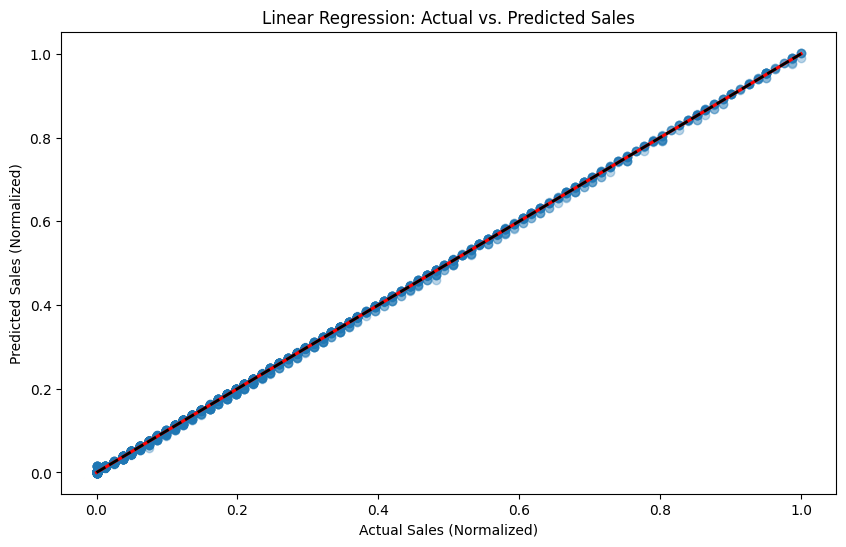

In [13]:
# 7. VISUALIZATION: ACTUAL VS. PREDICTED
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Linear Regression: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales (Normalized)')
plt.ylabel('Predicted Sales (Normalized)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Perfect prediction line
plt.show()